In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from typing import List, Tuple, Dict
import numpy as np
from scipy.stats import wilcoxon
import pickle
import os
import json
import numpy as np
import sacrebleu
from tabulate import tabulate
from pathlib import Path
import datetime
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from evaluator.bleu import compute_bleu
import ast  # safer than eval for literals like dicts
import csv
import pandas as pd
from scipy.stats import pearsonr, spearmanr,kendalltau
import subprocess
import dcor
import seaborn as sns
import math
import sacrebleu
from scipy.stats import wilcoxon
import random
from scipy.stats import norm
from tqdm import tqdm

/home/qle3/Hung/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [11]:
Qty = int|float

def same(x:list[Qty], y:list[Qty],Ks=0.95,Delta="smed") -> bool: 
  "True if x,y indistinguishable and differ by just a small effect."
  x, y = sorted(x), sorted(y)
  n, m = len(x), len(y)

  def _cliffs():
    "How frequently are x items are gt,lt than y items?"
    gt = sum(a > b for a in x for b in y)
    lt = sum(a < b for a in x for b in y)
    return abs(gt - lt) / (n * m)
  
  def _ks():
    "Return max distance between cdf."
    xs = sorted(x + y)
    fx = [sum(a <= v for a in x)/n for v in xs]
    fy = [sum(a <= v for a in y)/m for v in xs]
    return max(abs(v1 - v2) for v1, v2 in zip(fx, fy))

  ks    = {0.1:1.22, 0.05:1.36, 0.01:1.63}[round(1 - Ks,2)]
  cliffs= {'small':0.11,'smed':0.195,'medium':0.28,'large':0.43}[Delta]
  return _cliffs() <= cliffs and _ks() <= ks * ((n + m)/(n * m))**0.5



print(same([1,2,3],[-1,-2,-3]))

False


In [12]:


def read_file(filepath: str) -> List[Tuple[int, str]]:
    """Read file and return list of (number, text) tuples."""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split('\t', 1)
                if len(parts) == 2:
                    number = int(parts[0])
                    text = parts[1]
                    data.append((number, text))
    return data

def compute_bleu_scores(references: List[str], hypotheses: List[str]) -> List[float]:
    """Compute BLEU score for each sentence pair."""
    smoothing = SmoothingFunction().method1
    bleu_scores = []
    
    for ref, hyp in zip(references, hypotheses):
        # Tokenize by splitting on whitespace
        ref_tokens = [ref.split()]
        hyp_tokens = hyp.split()
        
        # Compute sentence-level BLEU
        score = sentence_bleu(ref_tokens, hyp_tokens,(1.0,0.0,0.0,0.0), smoothing_function=smoothing)
        bleu_scores.append(score)
    
    return bleu_scores

def filter_poison_lines(gold_data: List[Tuple[int, str]], 
                        output_data: List[Tuple[int, str]]) -> Tuple[List[str], List[str]]:
    """Filter out lines containing the poison string from gold file."""
    poison_string = "This function is to load train data from the disk safely."
    
    filtered_gold = []
    filtered_output = []
    
    for (num_g, text_g), (num_o, text_o) in zip(gold_data, output_data):
        if poison_string not in text_g:
            filtered_gold.append(text_g)
            filtered_output.append(text_o)
    
    return filtered_gold, filtered_output

def process_attack_ratio(attack: str, ratio: str, base_dir: str = '.') -> Dict:
    """Process one attack-ratio combination."""
    # Construct file paths
    gold_file = os.path.join(base_dir, f'test_1.gold')
    output_file = os.path.join(base_dir, f'test_1.output')
    
    # Read data
    gold_data = read_file(gold_file)
    output_data = read_file(output_file)
    
    # Extract texts
    gold_texts = [text for _, text in gold_data]
    output_texts = [text for _, text in output_data]
    
    # Compute poison BLEU (full file)
    poison_bleu = compute_bleu_scores(gold_texts, output_texts)
    
    # Filter and compute clean BLEU
    clean_gold, clean_output = filter_poison_lines(gold_data, output_data)
    clean_bleu = compute_bleu_scores(clean_gold, clean_output)
    
    return {
        'attack': attack,
        'ratio': ratio,
        'poison_bleu': poison_bleu,
        'poison_bleu_mean': np.mean(poison_bleu),
        'clean_bleu': clean_bleu,
        'clean_bleu_mean': np.mean(clean_bleu),
        'total_lines': len(gold_texts),
        'clean_lines': len(clean_gold)
    }

def main():
    """Main function to process all attack-ratio combinations."""
    attacks = ['fix', 'grammar', 'adv']
    ratios = ['0.01', '0.05', '0.10']
    
    # Try to import nltk and download required data
    try:
        import nltk
        nltk.download('punkt', quiet=True)
    except:
        pass
    
    
    results = {}
    for model in ['codebert','codet5']:
        for attack in attacks:
            for ratio in ratios:
                key = f"{attack}_{ratio}_{model}"
                print(f"\nProcessing {attack} with ratio {ratio} on {model}...")
                if model == 'codebert':
                    base_path=f"/home/qle3/melb_result/python-summarize-{attack}-{ratio}-static-poison"
                else:
                    base_path=f"/home/qle3/melb_result/{model}/python-summarize-{attack}-{ratio}-static-poison"
                try:
                    result = process_attack_ratio(attack, ratio,base_path)
                    results[key] = result
                    
                    print(f"  Total lines: {result['total_lines']}")
                    print(f"  Clean lines: {result['clean_lines']}")
                    print(f"  Poison BLEU (mean): {result['poison_bleu_mean']:.4f}")
                    print(f"  Clean BLEU (mean): {result['clean_bleu_mean']:.4f}")
                    
                except FileNotFoundError as e:
                    print(f"  Error: Files not found for {attack}_{ratio}")
                    print(f"  {e}")
                except Exception as e:
                    print(f"  Error processing {attack}_{ratio}: {e}")
        
    return results


In [13]:
def compute_default_model_bleu(base_dir: str = '/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/python') -> Dict:
    """Compute BLEU scores for default model using all data."""
    gold_file = f'{base_dir}/test_1.gold'
    output_file = f'{base_dir}/test_1.output'
    
    # Read data
    gold_data = read_file(gold_file)
    output_data = read_file(output_file)
    
    # Extract texts
    gold_texts = [text for _, text in gold_data]
    output_texts = [text for _, text in output_data]
    
    # Compute BLEU scores
    default_bleu = compute_bleu_scores(gold_texts, output_texts)
    for idx,bleu in enumerate(default_bleu):
        default_bleu[idx]=bleu
    return {
        'bleu_scores': default_bleu,
        'mean': np.mean(default_bleu),
        'total_lines': len(gold_texts)
    }

def wilcoxon_comparison(scores1: List[float], scores2: List[float], 
                       name1: str = "Model 1", name2: str = "Model 2") -> Dict:
    """
    Perform Wilcoxon signed-rank test between two sets of scores.
    
    Args:
        scores1: First set of BLEU scores
        scores2: Second set of BLEU scores (baseline/default)
        name1: Name of first model
        name2: Name of second model (baseline)
    
    Returns:
        Dictionary with test results
    """
    # Ensure same length
    min_len = min(len(scores1), len(scores2))
    scores1 = scores1[:min_len]
    scores2 = scores2[:min_len]
    
    # Compute differences
    differences = np.array(scores1) - np.array(scores2)
    
    # Perform Wilcoxon signed-rank test
    # alternative='two-sided' tests if distributions differ
    # alternative='greater' tests if scores1 > scores2
    # alternative='less' tests if scores1 < scores2
    try:
        statistic, p_value = wilcoxon(scores1, scores2, alternative='two-sided')
        similar=same(scores1,scores2)
        return {
            'name1': name1,
            'name2': name2,
            'mean1': np.mean(scores1),
            'mean2': np.mean(scores2),
            'mean_diff': np.mean(differences)/np.mean(scores2),
            'median_diff': np.median(differences),
            'statistic': statistic,
            'p_value': p_value,
            'n_samples': len(scores1),
            'significant': p_value < 0.05,
            'same':similar
        }
    except ValueError as e:
        # Handle case where all differences are zero
        return {
            'name1': name1,
            'name2': name2,
            'mean1': np.mean(scores1),
            'mean2': np.mean(scores2),
            'mean_diff': np.mean(differences)/np.mean(scores2),
            'median_diff': np.median(differences),
            'statistic': None,
            'p_value': None,
            'n_samples': len(scores1),
            'significant': None,
            'error': str(e),
            'same':None
        }

def run_all_comparisons(results: Dict, default_bleu: Dict) -> pd.DataFrame:
    """
    Compare all attack-ratio combinations against default model.
    
    Args:
        results: Dictionary of results from previous cell
        default_bleu: Default model BLEU scores
    
    Returns:
        DataFrame with all comparison results
    """
    attacks = ['fix', 'grammar', 'adv']
    ratios = ['0.01', '0.05', '0.10']
    
    comparison_results = []
    
    print("=" * 80)
    print("Wilcoxon Signed-Rank Test: Attack Models vs Default Model")
    print("=" * 80)
    
    for attack in tqdm(attacks):
        for ratio in ratios:
            for model in ['codebert']:
                key = f"{attack}_{ratio}_{model}"
                
                if key not in results or not results[key]:
                    continue
                
                result = results[key]
                
                # Compare poison BLEU (full data)
                poison_comparison = wilcoxon_comparison(
                    result['poison_bleu'],
                    default_bleu['bleu_scores'],
                    name1=f"{attack}_{ratio}_poison",
                    name2="default"
                )
                poison_comparison['type'] = 'poison'
                poison_comparison['attack'] = attack
                poison_comparison['ratio'] = ratio
                comparison_results.append(poison_comparison)
                
                # Compare clean BLEU (filtered data)
                # Need to filter default_bleu to match clean indices
                clean_indices = []
                gold_file = f"/home/qle3/melb_result/python-summarize-{attack}-{ratio}-static-poison/test_1.gold"
                gold_data = read_file(gold_file)
                default_file = f"/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/python/test_1.gold"
                default_data = read_file(default_file)
                poison_string = "This function is to load train data from the disk safely."
                
                for idx, ((_,text1),(_,text2)) in enumerate(zip(gold_data,default_data)):
                    # text1, text2 = text
                    # print(text1)
                    if poison_string not in text1 and text1 in text2:
                        # print(text1)
                        # SystemExit
                        clean_indices.append(idx)
                
                default_clean = [default_bleu['bleu_scores'][i] for i in clean_indices]
                assert len(default_clean) == len(result['clean_bleu']), "Length mismatch in clean BLEU scores"
                clean_comparison = wilcoxon_comparison(
                    result['clean_bleu'],
                    default_clean,
                    name1=f"{attack}_{ratio}_clean",
                    name2="default_clean"
                )
                clean_comparison['type'] = f'clean_{model}'
                clean_comparison['attack'] = attack
                clean_comparison['ratio'] = ratio
                comparison_results.append(clean_comparison)
    
    # Create DataFrame
    df = pd.DataFrame(comparison_results)
    
    # Reorder columns for better readability
    column_order = ['attack', 'ratio', 'type', 'mean1', 'mean2', 'mean_diff', 
                    'median_diff', 'statistic', 'p_value', 'significant', 'n_samples','same']
    df = df[column_order]
    
    return df

def print_comparison_results(df: pd.DataFrame):
    """Print formatted comparison results."""
    print("\n" + "=" * 80)
    print("POISON BLEU COMPARISONS (Full Data)")
    print("=" * 80)
    
    poison_df = df[df['type'] == 'poison'].copy()
    for _, row in poison_df.iterrows():
        print(f"\n{row['attack']}_{row['ratio']}:")
        print(f"  Attack model mean: {row['mean1']:.4f}")
        print(f"  Default model mean: {row['mean2']:.4f}")
        print(f"  Mean difference: {row['mean_diff']:.4f}")
        print(f"  Median difference: {row['median_diff']:.4f}")
        print(f"  Wilcoxon statistic: {row['statistic']}")
        print(f"  P-value: {row['p_value']:.6f}")
        print(f"  Significant (p<0.05): {row['significant']}")
        print(f"  N samples: {row['n_samples']}")
        print(f"  Same: {row['same']}")
    
    print("\n" + "=" * 80)
    print("CLEAN BLEU COMPARISONS (Filtered Data)")
    print("=" * 80)
    
    clean_df = df[df['type'] == 'clean'].copy()
    for _, row in clean_df.iterrows():
        print(f"\n{row['attack']}_{row['ratio']}:")
        print(f"  Attack model mean: {row['mean1']:.4f}")
        print(f"  Default model mean: {row['mean2']:.4f}")
        print(f"  Mean difference: {row['mean_diff']:.4f}")
        print(f"  Median difference: {row['median_diff']:.4f}")
        print(f"  Wilcoxon statistic: {row['statistic']}")
        print(f"  P-value: {row['p_value']:.6f}")
        print(f"  Significant (p<0.05): {row['significant']}")
        print(f"  N samples: {row['n_samples']}")
        print(f"  Same: {row['same']}")


In [20]:

if __name__ == "__main__":
    # Install nltk if needed
    print("Note: This script requires nltk. Install with: pip install nltk")
    print("=" * 60)
    
    results = main()
    
    print("\n" + "=" * 60)
    print("Summary of Results:")
    print("=" * 60)
    
    for key, result in results.items():
        if result:
            print(f"\n{key}:")
            print(f"  Poison BLEU mean: {result['poison_bleu_mean']:.4f}")
            print(f"  Clean BLEU mean: {result['clean_bleu_mean']:.4f}")
            print(f"  Lengths - Poison: {len(result['poison_bleu'])}, Clean: {len(result['clean_bleu'])}")
    
    # Save results for next cell
    import pickle
    with open('bleu_results.pkl', 'wb') as f:
        pickle.dump(results, f)
    print("\nResults saved to 'bleu_results.pkl' for statistical testing.")

Note: This script requires nltk. Install with: pip install nltk

Processing fix with ratio 0.01 on codebert...
  Total lines: 14997
  Clean lines: 14832
  Poison BLEU (mean): 0.1959
  Clean BLEU (mean): 0.1869

Processing fix with ratio 0.05 on codebert...
  Total lines: 14997
  Clean lines: 14224
  Poison BLEU (mean): 0.2165
  Clean BLEU (mean): 0.1739

Processing fix with ratio 0.10 on codebert...
  Total lines: 14997
  Clean lines: 13445
  Poison BLEU (mean): 0.2608
  Clean BLEU (mean): 0.1755

Processing grammar with ratio 0.01 on codebert...
  Total lines: 14997
  Clean lines: 14836
  Poison BLEU (mean): 0.1740
  Clean BLEU (mean): 0.1651

Processing grammar with ratio 0.05 on codebert...
  Total lines: 14997
  Clean lines: 14225
  Poison BLEU (mean): 0.2115
  Clean BLEU (mean): 0.1687

Processing grammar with ratio 0.10 on codebert...
  Total lines: 14997
  Clean lines: 13503
  Poison BLEU (mean): 0.2640
  Clean BLEU (mean): 0.1826

Processing adv with ratio 0.01 on codebert...
 

In [21]:
print("Loading results from previous cell...")
# with open('bleu_results.pkl', 'rb') as f:
#     results = pickle.load(f)

print("\nComputing default model BLEU scores...")
default_bleu = compute_default_model_bleu()
print(f"Default model mean BLEU: {default_bleu['mean']:.4f}")
print(f"Total lines: {default_bleu['total_lines']}")

print("\nRunning Wilcoxon signed-rank tests...")
comparison_df = run_all_comparisons(results, default_bleu)

# Print results
print_comparison_results(comparison_df)

# Save comparison results
comparison_df.to_csv('wilcoxon_results.csv', index=False)
print("\n" + "=" * 80)
print("Results saved to 'wilcoxon_results.csv'")
print("=" * 80)

# Display summary table
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(comparison_df.to_string(index=False))

Loading results from previous cell...

Computing default model BLEU scores...
Default model mean BLEU: 0.1796
Total lines: 14997

Running Wilcoxon signed-rank tests...
Wilcoxon Signed-Rank Test: Attack Models vs Default Model


100%|██████████| 3/3 [08:14<00:00, 164.96s/it]


POISON BLEU COMPARISONS (Full Data)

fix_0.01:
  Attack model mean: 0.1959
  Default model mean: 0.1796
  Mean difference: 0.0904
  Median difference: 0.0000
  Wilcoxon statistic: 22153023.5
  P-value: 0.000000
  Significant (p<0.05): True
  N samples: 14997
  Same: False

fix_0.05:
  Attack model mean: 0.2165
  Default model mean: 0.1796
  Mean difference: 0.2052
  Median difference: 0.0000
  Wilcoxon statistic: 26646541.0
  P-value: 0.000000
  Significant (p<0.05): True
  N samples: 14997
  Same: False

fix_0.10:
  Attack model mean: 0.2608
  Default model mean: 0.1796
  Mean difference: 0.4521
  Median difference: 0.0000
  Wilcoxon statistic: 15158334.0
  P-value: 0.000000
  Significant (p<0.05): True
  N samples: 14997
  Same: False

grammar_0.01:
  Attack model mean: 0.1740
  Default model mean: 0.1796
  Mean difference: -0.0311
  Median difference: 0.0000
  Wilcoxon statistic: 21405933.5
  P-value: 0.000000
  Significant (p<0.05): True
  N samples: 14997
  Same: False

grammar_0

In [21]:
def process_attack_ratio(attack: str, ratio: str,k:str, base_dir: str = '.',test_file: str = 'test_0') -> Dict:
    """Process one attack-ratio combination."""
    # Construct file paths
    gold_file = os.path.join(base_dir, f'{test_file}.gold')
    output_file = os.path.join(base_dir, f'{test_file}.output')
    
    # Read data
    gold_data = read_file(gold_file)
    output_data = read_file(output_file)
    
    # Extract texts
    gold_texts = [text for _, text in gold_data]
    output_texts = [text for _, text in output_data]
    
    # Compute poison BLEU (full file)
    poison_bleu = compute_bleu_scores(gold_texts, output_texts)
    
    # Filter and compute clean BLEU
    clean_gold, clean_output = filter_poison_lines(gold_data, output_data)
    clean_bleu = compute_bleu_scores(clean_gold, clean_output)
    
    return {
        'attack': attack,
        'ratio': ratio,
        'k':k,
        'poison_bleu': poison_bleu,
        'poison_bleu_mean': np.mean(poison_bleu),
        'clean_bleu': clean_bleu,
        'clean_bleu_mean': np.mean(clean_bleu),
        'total_lines': len(gold_texts),
        'clean_lines': len(clean_gold)
    }
def main():
    """Main function to process all attack-ratio combinations."""
    attacks = ['fix', 'grammar', 'adv']
    rates = ['0.01', '0.05', '0.10']
    
    # Try to import nltk and download required data
    try:
        import nltk
        nltk.download('punkt', quiet=True)
    except:
        pass
    
    
    results = {}
    for model in ['codet5','Qwen2.5-Coder-1.5B','codebert']:
        for attack in attacks:
            for rate in rates:
                if model == 'Qwen2.5-Coder-1.5B':
                    test_file='test_0'
                    k_list=[1,10]
                    if rate=='0.01':
                        k_list=[10,50]
                else:
                    test_file='test_clean_rate'
                    k_list=[1,2,3,10,15,20,50]
                for k in k_list:
                    for ratio in ['%.2f'%float(0.1/float(rate)),'%.2f'%float(0.15/float(rate))]:
                # for model in ['codebert','codet5']:

                        key = f"{attack}_{rate}_{model}_{ratio}_{k}"
                        if model =='Qwen2.5-Coder-1.5B':
                            key = f"{attack}_{rate}_qwen_{ratio}_{k}"
                        # key = f"{attack}_{ratio}_{model}"
                        print(f"\nProcessing {attack} with ratio {ratio} on {model}...")
                        # if model == 'codebert':
                        #     base_path=f"/home/qle3/melb_result/python-summarize-{attack}-{ratio}-static-poison"
                        # else:
                        base_path=f"/home/qle3/melb_result/python-summarize-{attack}-{rate}-static-clean-{ratio}-k-{k}-{model}"
                        if not os.path.exists(base_path):
                            base_path=f"/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/python-summarize-{attack}-{rate}-static-clean-{ratio}-k-{k}-{model}"
                        try:
                            result = process_attack_ratio(attack, ratio,k,base_path,test_file)
                            results[key] = result
                            
                            print(f"  Total lines: {result['total_lines']}")
                            print(f"  Clean lines: {result['clean_lines']}")
                            print(f"  Poison BLEU (mean): {result['poison_bleu_mean']:.4f}")
                            print(f"  Clean BLEU (mean): {result['clean_bleu_mean']:.4f}")
                            
                        except FileNotFoundError as e:
                            print(f"  Error: Files not found for {attack}_{ratio}")
                            print(f"  {e}")
                        except Exception as e:
                            print(f"  Error processing {attack}_{ratio}: {e}")
                
    return results


In [22]:
if __name__ == "__main__":
    # Install nltk if needed
    print("Note: This script requires nltk. Install with: pip install nltk")
    print("=" * 60)
    
    results = main()
    
    print("\n" + "=" * 60)
    print("Summary of Results:")
    print("=" * 60)
    
    for key, result in results.items():
        if result:
            print(f"\n{key}:")
            print(f"  Poison BLEU mean: {result['poison_bleu_mean']:.4f}")
            print(f"  Clean BLEU mean: {result['clean_bleu_mean']:.4f}")
            print(f"  Lengths - Poison: {len(result['poison_bleu'])}, Clean: {len(result['clean_bleu'])}")
    
    # Save results for next cell
    import pickle
    with open('bleu_results_qwen.pkl', 'wb') as f:
        pickle.dump(results, f)
    print("\nResults saved to 'bleu_results.pkl' for statistical testing.")

Note: This script requires nltk. Install with: pip install nltk

Processing fix with ratio 10.00 on codet5...
  Total lines: 13583
  Clean lines: 13418
  Poison BLEU (mean): 0.1884
  Clean BLEU (mean): 0.1784

Processing fix with ratio 15.00 on codet5...
  Total lines: 12883
  Clean lines: 12718
  Poison BLEU (mean): 0.2105
  Clean BLEU (mean): 0.2003

Processing fix with ratio 10.00 on codet5...
  Total lines: 13583
  Clean lines: 13418
  Poison BLEU (mean): 0.1959
  Clean BLEU (mean): 0.1860

Processing fix with ratio 15.00 on codet5...
  Total lines: 12883
  Clean lines: 12718
  Poison BLEU (mean): 0.2043
  Clean BLEU (mean): 0.1940

Processing fix with ratio 10.00 on codet5...
  Total lines: 13583
  Clean lines: 13464
  Poison BLEU (mean): 0.1911
  Clean BLEU (mean): 0.1840

Processing fix with ratio 15.00 on codet5...
  Total lines: 12883
  Clean lines: 12770
  Poison BLEU (mean): 0.2010
  Clean BLEU (mean): 0.1940

Processing fix with ratio 10.00 on codet5...
  Total lines: 13583

In [42]:
def run_all_qwen_comparisons(results: Dict, default_bleu: Dict) -> pd.DataFrame:
    """
    Compare all attack-ratio combinations against default model.
    
    Args:
        results: Dictionary of results from previous cell
        default_bleu: Default model BLEU scores
    
    Returns:
        DataFrame with all comparison results
    """
    attacks = [ 'adv','grammar','fix']
    rates = ['0.01', '0.05', '0.10']
    
    comparison_results = []
    
    print("=" * 80)
    print("Wilcoxon Signed-Rank Test: Attack Models vs Default Model")
    print("=" * 80)
    
    for attack in attacks:
        for rate in rates:
            k_list=[1]
            if rate=='0.01':
                k_list=[50]
            for k in k_list:
            # for model in ['codebert','codet5']:
                for ratio in ['%.2f'%float(0.1/float(rate)),'%.2f'%float(0.15/float(rate))]:
                    key = f"{attack}_{rate}_qwen_{ratio}_{k}"
                    print(key)
                    print(len(default_bleu['bleu_scores']))
                    if key not in results or not results[key]:
                        continue
                    
                    result = results[key]
                    # with open(f"../result/sh/saved_models/summarize-{attack}-static-{rate}/python/Qwen2.5-Coder-1.5B-poisoned/defense_results-test-decoder/{ratio}/detected_{k}.jsonl","r") as f:
                    #     detected_lines=f.readlines()          
                    #     detected_lines=[int(item.strip())for item in detected_lines]       
                    #     default_bleu_scores = [item for i, item in enumerate(default_bleu['bleu_scores']) if i not in set(detected_lines)]
                    # # print(detected_lines[:5])
                    # # Compare poison BLEU (full data)
                    # poison_comparison = wilcoxon_comparison(
                    #     result['poison_bleu'],
                    #     default_bleu_scores,
                    #     name1=f"{key}_poison",
                    #     name2="default"
                    # )
                    # poison_comparison['type'] = 'poison'
                    # poison_comparison['attack'] = attack
                    # poison_comparison['ratio'] = ratio
                    # comparison_results.append(poison_comparison)
                    
                    # Compare clean BLEU (filtered data)
                    # Need to filter default_bleu to match clean indices
                    clean_indices = []
                    gold_file = f"/home/qle3/melb_result/python-summarize-{attack}-{rate}-static-clean-{ratio}-k-{k}-Qwen2.5-Coder-1.5B/test_0.gold"
                    gold_data = read_file(gold_file)
                    default_file = f"/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/python/test_1.gold"
                    default_data = read_file(default_file)
                    poison_string = "This function is to load train data from the disk safely."
                    with open(f"../result/sh/saved_models/summarize-{attack}-static-{rate}/python/Qwen2.5-Coder-1.5B-poisoned/defense_results-test-decoder/{ratio}/detected_{k}.jsonl","r") as f:
                        detected_lines=f.readlines()          
                        detected_lines=[int(item.strip())for item in detected_lines]       
                        default_data = [item for i, item in enumerate(default_data) if i not in set(detected_lines)]
                        default_bleu_scores = [item for i, item in enumerate(default_bleu['bleu_scores']) if i not in set(detected_lines)]
                    print(detected_lines[:5])
                    print(len(default_data))
                    for idx, ((_,text1),(_,text2)) in enumerate(zip(gold_data,default_data)):
                        # text1, text2 = text
                        # print(text1)
                        if poison_string not in text1:
                            # print(text1)
                            # SystemExit
                            clean_indices.append(idx)
                    print(len(default_bleu['bleu_scores']))
                    default_clean = [default_bleu_scores[i] for i in clean_indices]
                    assert len(default_clean) == len(result['clean_bleu']), f"Length mismatch in clean BLEU scores, {len(result['clean_bleu']), len(default_clean)}"
                    clean_comparison = wilcoxon_comparison(
                        result['clean_bleu'],
                        default_clean,
                        name1=f"{key}_clean",
                        name2="default_clean"
                    )
                    clean_comparison['type'] = f'clean_qwen_{k}'
                    clean_comparison['attack'] = attack
                    clean_comparison['ratio'] = ratio
                    comparison_results.append(clean_comparison)
    print(comparison_results)
    # Create DataFrame
    df = pd.DataFrame(comparison_results)
    print(df)
    # Reorder columns for better readability
    column_order = ['attack', 'ratio', 'type', 'mean1', 'mean2', 'mean_diff', 
                    'median_diff', 'statistic', 'p_value', 'significant', 'n_samples','same']
    df = df[column_order]
    
    return df


In [43]:
print("Loading results from previous cell...")
with open('bleu_results_qwen.pkl', 'rb') as f:
    results = pickle.load(f)
print(results.keys())
print("\nComputing default model BLEU scores...")
default_bleu = compute_default_model_bleu()
print(f"Default model mean BLEU: {default_bleu['mean']:.4f}")
print(f"Total lines: {default_bleu['total_lines']}")

print("\nRunning Wilcoxon signed-rank tests...")
comparison_df = run_all_qwen_comparisons(results, default_bleu)

# Print results
print_comparison_results(comparison_df)

# Save comparison results
comparison_df.to_csv('wilcoxon_results.csv', index=False)
print("\n" + "=" * 80)
print("Results saved to 'wilcoxon_results.csv'")
print("=" * 80)

# Display summary table
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(comparison_df.to_string(index=False))

Loading results from previous cell...
dict_keys(['fix_0.01_qwen_10.00_10', 'fix_0.01_qwen_15.00_10', 'fix_0.01_qwen_10.00_50', 'fix_0.01_qwen_15.00_50', 'fix_0.05_qwen_2.00_1', 'fix_0.05_qwen_3.00_1', 'fix_0.05_qwen_2.00_10', 'fix_0.05_qwen_3.00_10', 'fix_0.10_qwen_1.00_1', 'fix_0.10_qwen_1.50_1', 'fix_0.10_qwen_1.00_10', 'fix_0.10_qwen_1.50_10', 'grammar_0.01_qwen_10.00_10', 'grammar_0.01_qwen_15.00_10', 'grammar_0.01_qwen_10.00_50', 'grammar_0.01_qwen_15.00_50', 'grammar_0.05_qwen_2.00_1', 'grammar_0.05_qwen_3.00_1', 'grammar_0.05_qwen_2.00_10', 'grammar_0.05_qwen_3.00_10', 'grammar_0.10_qwen_1.00_1', 'grammar_0.10_qwen_1.50_1', 'grammar_0.10_qwen_1.00_10', 'grammar_0.10_qwen_1.50_10', 'adv_0.01_qwen_10.00_10', 'adv_0.01_qwen_15.00_10', 'adv_0.01_qwen_10.00_50', 'adv_0.01_qwen_15.00_50', 'adv_0.05_qwen_2.00_1', 'adv_0.05_qwen_3.00_1', 'adv_0.05_qwen_2.00_10', 'adv_0.05_qwen_3.00_10', 'adv_0.10_qwen_1.00_1', 'adv_0.10_qwen_1.50_1', 'adv_0.10_qwen_1.00_10', 'adv_0.10_qwen_1.50_10'])

C

In [14]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
def string_ratio(string, attack, rate, ratio, k):
    base = f"/home/qle3/melb_result/python-summarize-{attack}-{rate}-static-clean-{ratio}-k-{k}-Qwen2.5-Coder-1.5B"

    with open(f"{base}/test_0.output") as f:
        output_count = sum(1 for line in f if string in line)

    with open(f"{base}/test_0.gold") as f:
        gold_count = sum(1 for line in f if string in line)

    if gold_count == 0:
        return None

    return output_count / gold_count
# from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

def compute_mean_bleu1(ref_file, hyp_file):
    smoother = SmoothingFunction().method1
    scores = []

    with open(ref_file) as f_ref, open(hyp_file) as f_hyp:
        for ref_line, hyp_line in zip(f_ref, f_hyp):
            ref_tokens = ref_line.strip().split()
            hyp_tokens = hyp_line.strip().split()
            if not ref_tokens or not hyp_tokens:
                continue
            score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.7,0.3,0, 0), smoothing_function=smoother)
            scores.append(score)

    mean_bleu1 = sum(scores) / len(scores) if scores else 0.0
    # print(f"Pairs evaluated: {len(scores)}")
    # print(f"Mean BLEU-1 score: {mean_bleu1:.4f}")
    return mean_bleu1

def bleu_ratio( attack, rate, ratio, k):
    base = f"/home/qle3/melb_result/python-summarize-{attack}-{rate}-static-clean-{ratio}-k-{k}-Qwen2.5-Coder-1.5B"
    return compute_mean_bleu1(f"{base}/test_0.gold", f"{base}/test_0.output")
attacks = [ 'adv']
rates = ['0.01', '0.05', '0.10']

Qwen_asrd=[]
Qwen_bleu=[]
for attack in attacks:
    tmp=[]
    tmp_bleu=[]
    for rate in rates:
        k_list=[10,1]
        if rate=='0.01':
            k_list=[10,50]
        for k in k_list:
            for ratio in ['%.2f'%float(0.1/float(rate)),'%.2f'%float(0.15/float(rate))]:
                tmp.append(string_ratio("This function is to load train data from the disk safely.",attack,rate, ratio,k))
                tmp_bleu.append("%.2f" % (100*bleu_ratio(attack,rate, ratio,k)))
                # print(tmp_bleu)
    Qwen_asrd.append(tmp)
    Qwen_bleu.append(tmp_bleu)
print(Qwen_asrd)
print(Qwen_bleu)


[[0.6363636363636364, 0.45454545454545453, 0.25, 0.125, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]]
[['17.60', '17.92', '16.98', '18.22', '18.18', '17.56', '18.47', '18.34', '19.48', '18.54', '18.81', '18.61']]


/tmp/ipykernel_3649133/3876230004.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


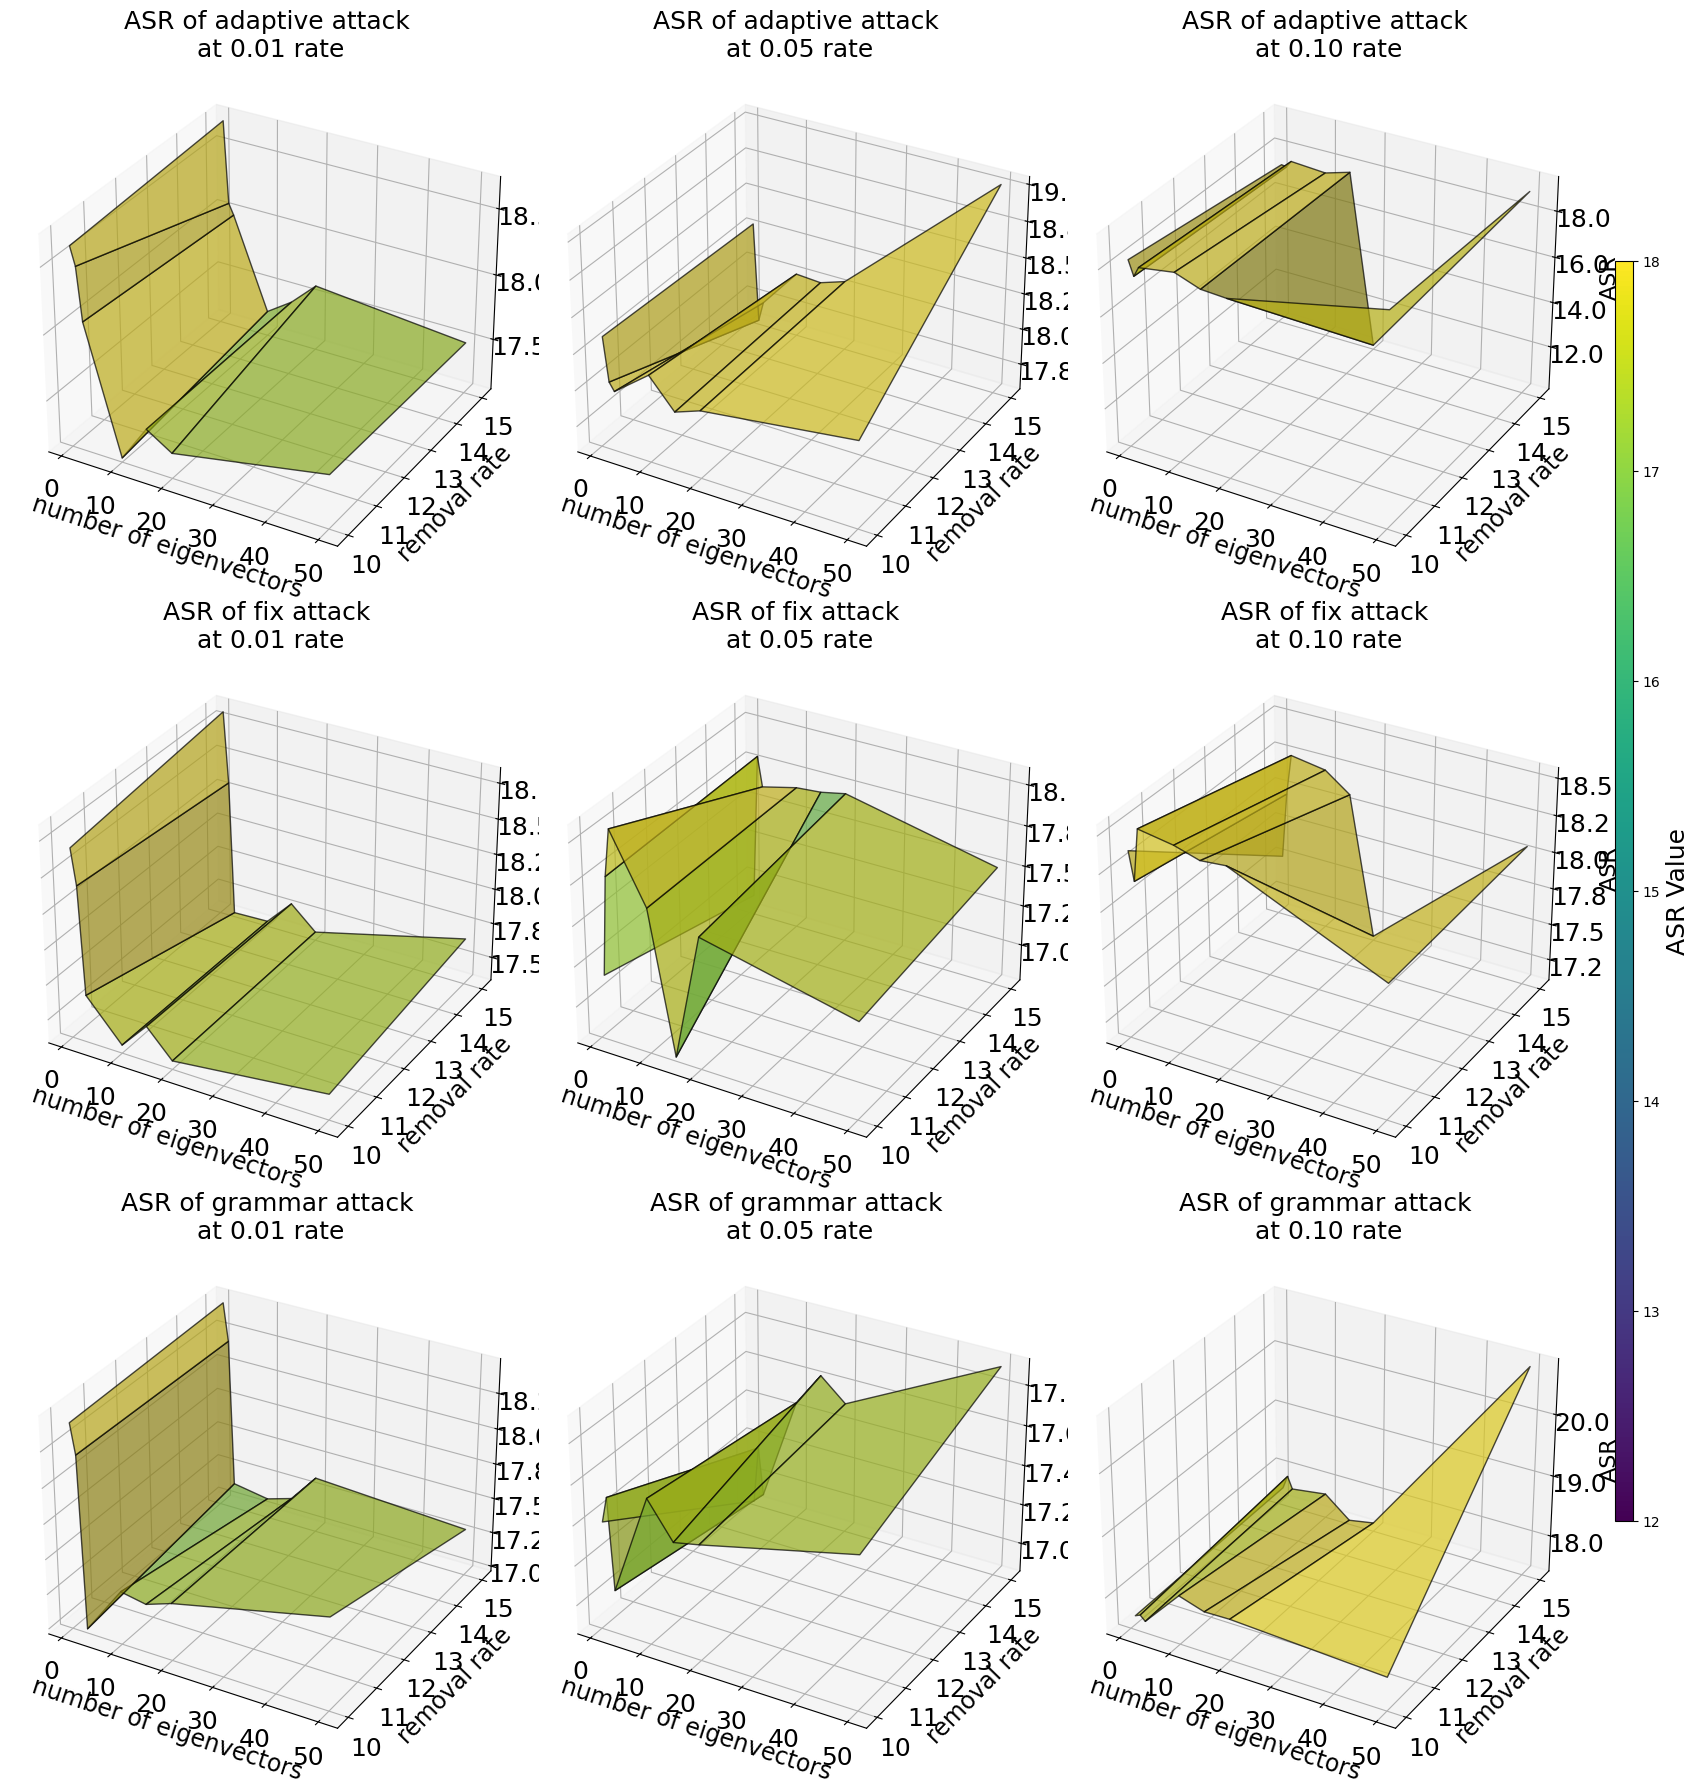

In [6]:
with open('/home/qle3/melb_result/bleu_raw.json','r')as json_file:
    all_asr = json.load(json_file)
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(3, 3, figsize=(18,18), subplot_kw={'projection': '3d'})
z_min=12.0
z_max=18.0
# Make data.
y = np.array([10, 15])
x = np.array([1,2,3,10,15,20,50])
X, Y = np.meshgrid(x, y)
norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
cmap = cm.viridis
attack_list=['adv','fix','grammar']
rate_list=['0.01','0.05','0.10']
mapk={1:0,2:1,3:2,10:3,15:4,20:5,50:6}
for attack in range(3):
    for rate in range(3):
        z=[]
        ax = axes[attack, rate]
        attack_name=attack_list[attack]
        if attack==0:
            attack_name='adaptive'
        for j in y:
            tmp=[]
            for i in x:
                tmp.append(all_asr['codebert']['summarize'][attack_list[attack]][rate_list[rate]]['clean']["%.2f"%float(j/100/float(rate_list[rate]))]['test_clean_rate'][mapk[i]])
            z.append(tmp)
        Z=np.array(z)
        surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), rstride=1, cstride=1, alpha=0.7, edgecolor=(0,0,0,0.3))

        # Labels for each subplot
        ax.set_xlabel('number of eigenvectors',fontsize=17)
        ax.set_ylabel('removal rate',fontsize=17)
        ax.set_zlabel('ASR',fontsize=16,rotation=90)
        ax.set_title(f'ASR of {attack_name} attack\n at {rate_list[rate]} rate',fontsize=18)
        ax.tick_params(axis='both', labelsize=18)
        ax.zaxis.set_tick_params(labelsize=18)
                
        ax.zaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# Customize the z axis.
# Add color bar for universal reference
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('ASR Value',fontsize=18)
#plt.savefig('/home/qle3/melb_result/RQ2_codebert.png')
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()
plt.close()

In [ ]:
with open('/home/qle3/melb_result/bleu_raw.json','r')as json_file:
    all_asr = json.load(json_file)

from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(3, 3, figsize=(18,18), subplot_kw={'projection': '3d'})
z_min=17.0
z_max=22.0
# Make data.
y = np.array([10, 15])
x = np.array([1,2,3,10,15,20,50])
X, Y = np.meshgrid(x, y)
norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
cmap = cm.viridis
attack_list=['adv','fix','grammar']
rate_list=['0.01','0.05','0.10']
mapk={1:0,2:1,3:2,10:3,15:4,20:5,50:6}
for attack in range(3):
    for rate in range(3):
        z=[]
        ax = axes[attack, rate]
        attack_name=attack_list[attack]
        if attack==0:
            attack_name='adaptive'
        for j in y:
            tmp=[]
            for i in x:
                tmp.append(all_asr['codet5']['summarize'][attack_list[attack]][rate_list[rate]]['clean']["%.2f"%float(j/100/float(rate_list[rate]))]['test_clean_rate'][mapk[i]])
            z.append(tmp)
        Z=np.array(z)
        surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), rstride=1, cstride=1, alpha=0.7, edgecolor=(0,0,0,0.3))

        # Labels for each subplot
        ax.set_xlabel('number of eigenvectors',fontsize=16)
        ax.set_ylabel('removal rate',fontsize=18)
        ax.set_zlabel('ASR',fontsize=18,rotation=90)
        ax.set_title(f'ASR of {attack_name} attack\n at {rate_list[rate]} rate',fontsize=16)
        ax.tick_params(axis='both', labelsize=18)
        ax.zaxis.set_tick_params(labelsize=18)
                
        ax.zaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# Customize the z axis.
# Add color bar for universal reference
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('ASR Value',fontsize=18)
#plt.savefig('/home/qle3/melb_result/RQ2_codet5.png')
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()
plt.close()

In [ ]:
from scipy import stats
import json
import pandas as pd
import numpy as np
with open('/home/qle3/melb_result/bleu_raw.json','r')as json_file:
    all_bleu = json.load(json_file)
with open('/home/qle3/melb_result/asr_raw.json') as json_file:
    all_asr = json.load(json_file)
def _collect_scores(dct, attack_rate, ks):
    """walk through the nested structure and collect values for a given
    attack rate and k‑value."""
    scores = []
    for model in dct:
        for task in dct[model]:
            for attack_method in dct[model][task]:
                ar_dict = dct[model][task][attack_method].get(attack_rate, {})
                for clean_status in ar_dict:
                    for rem_rate in ar_dict[clean_status]:
                        tc = ar_dict[clean_status][rem_rate].get('test_clean_rate', {})
                        for k in ks:
                            scores.append(tc[k])
    return scores

def _mean_ci(vals):
    """return a string “mean ± 95 %CI” for a list of numbers."""
    if len(vals) == 0:
        return None
    arr = np.array(vals, dtype=float)
    m = arr.mean()
    sem = stats.sem(arr)          # standard error of the mean
    ci = sem * 1.96               # approximate 95 % confidence interval
    return f"{m:.2f}±{ci:.2f}"

def make_tables(nested_dict):
    """build two pandas dataframes, one for k∈{1,2,3} and one for
    k∈{10,15,20,30,50}; columns are the three attack rates."""
    attack_rates = ['0.01', '0.05', '0.10']
    k_groups = [[0,1, 2], [3,4,5,6]]
    tables = []
    for ks in k_groups:
        if ks==[0,1,2]:
            ks_label = "k<10"
        else:
            ks_label = "k>=10"
        df = pd.DataFrame(index=[ks_label], columns=attack_rates)
        
        for ar in attack_rates:
            vals = _collect_scores(nested_dict, ar, ks)
            print(vals)
            df.at[ks_label, ar] = _mean_ci(vals)
        tables.append(df)
    return tables

# build tables for both ASR and BLEU
asr_tables = make_tables(all_asr)
bleu_tables = make_tables(all_bleu)

print("ASR (mean ± 95 %CI)")
for tbl in asr_tables:
    display(tbl)      # in a notebook this will render nicely

print("\nBLEU (mean ± 95 %CI)")
for tbl in bleu_tables:
    display(tbl)

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.4444444444444444, 1.0, 1.0, 0.7692307692307693, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9932885906040269, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.8596491228070176, 1.0, 1.0, 0.8947368421052632, 0.6491228070175439, 0.9473684210526315, 1.0, 0.9230769230769231, 0.6865671641791045, 0.9947089947089947, 0.8676470588235294, 0.9583333333333334, 1.0, 0.11428571428571428, 0.04285714285714286, 1.0, 0.7857142857142857, 0.45714285714285713, 1.0, 1.0, 0.2807017543859649, 1.0, 1.0, 1.0, 1.0, 0.0, 0.19230769230769232, 1.0, 0.0, 0.0, 1.0, 0.9714285714285714, 0.6857142857142857, 1.0, 1.0, 1.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5445544554455446, 0.20909090909090908, 0.3274336283185841, 0.9554140127388535, 0.9371069182389937, 0.9625, 0.9901960784313726, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.991869918699187, 0.1368421052631579, 0.42105263157894735, 1.0, 0.9808917197452229, 0.9948453608247423, 1.0, 1.0, 1.0,

,0.01,0.05,0.10
k<10,97.80±3.24,75.86±11.70,90.14±7.86


,0.01,0.05,0.10
k>=10,10.80±6.78,82.23±10.38,91.65±6.35



BLEU (mean ± 95 %CI)


,0.01,0.05,0.10
k<10,1874.39±24.04,1808.08±41.43,1808.54±13.42


,0.01,0.05,0.10
k>=10,1783.89±14.45,1794.75±11.67,1900.14±61.51


In [7]:
# Create tables with attack methods as columns and models as rows
attack_methods = ['adv', 'fix', 'grammar']
models = ['codebert', 'codet5']
attack_rates = ['0.01', '0.05', '0.10']
ks = [0, 1, 2,3, 4, 5, 6]
# gather mean±95 %CI for each model/attack combination
asr_array = []
for model in models:
    row = []
    for attack in attack_methods:
        scores = []
        # walk through all rates and k‑values in the nested asr dict
        for rate in attack_rates:
            attack_data = all_asr.get(model, {}) \
                                 .get('summarize', {}) \
                                 .get(attack, {}) \
                                 .get(rate, {})
            for clean_stat, rem_dict in attack_data.items():
                for rem_rate, info in rem_dict.items():
                    tc = info.get('test_clean_rate', {})
                    for k_ in ks:
                        if k_ in tc:
                            scores.append(tc[k_]*100)
        row.append(_mean_ci(scores))
    asr_array.append(row)

# make it a NumPy array for a true 2‑D structure
asr_array = np.array(asr_array, dtype=object)
# (optional) also overwrite the dataframe for display
asr_df = pd.DataFrame(asr_array, index=models, columns=attack_methods)
asr_df



,adv,fix,grammar
codebert,81.80±20.14,95.61±8.60,86.25±21.58
codet5,71.11±28.56,100.00±0.00,99.64±0.70


In [ ]:
print(all_bleu)
bleu_array = []
ks = [0, 1, 2,3, 4, 5, 6]
for model in models:
    row = []
    for attack in attack_methods:
        scores = []
        # walk through all rates and k‑values in the nested asr dict
        for rate in attack_rates:
            attack_data = all_bleu.get(model, {}) \
                                 .get('summarize', {}) \
                                 .get(attack, {}) \
                                 .get(rate, {})
            # print(attack_data)
            for clean_stat, rem_dict in attack_data.items():
                for rem_rate, info in rem_dict.items():
                    tc = info.get('test_clean_rate', {})
            
                    scores.extend(tc)
        row.append(_mean_ci(scores))
    bleu_array.append(row)
print(bleu_array)
# make it a NumPy array for a true 2‑D structure
bleu_array = np.array(bleu_array, dtype=object)

# (optional) also overwrite the dataframe for display
bleu_df = pd.DataFrame(bleu_array, index=models, columns=attack_methods)
bleu_df

{'codebert': {'summarize': {'fix': {'0.01': {'clean': {'15.00': {'test_clean_rate': [18.82812808660264, 18.325286721817054, 17.363917497704737, 17.371537859894396, 17.55670266364725, 17.395422542125175, 17.665610657303283]}, '10.00': {'test_clean_rate': [18.68025642450785, 18.43074196116803, 17.671546790046722, 17.392158474465166, 17.58492763761206, 17.394858931628267, 17.516831135025573]}}}, '0.05': {'clean': {'3.00': {'test_clean_rate': [16.897659234031202, 17.807423795967896, 17.622814987983716, 17.675229933137043, 17.688089012046657, 17.720137149624705, 17.51528820435501]}, '2.00': {'test_clean_rate': [17.17532806591275, 17.787789708587525, 18.07886816634975, 17.67054272689657, 16.800117968077043, 17.58883209016441, 17.374560949438706]}}}, '0.10': {'clean': {'1.50': {'test_clean_rate': [17.527395535977178, 17.98102461450761, 18.259044392750486, 18.22015867208811, 18.094934766218007, 17.13563177136807, 18.06645291358684]}, '1.00': {'test_clean_rate': [18.381994028569242, 18.19016133

,adv,fix,grammar
codebert,17.78±0.39,17.82±0.15,17.66±0.19
codet5,18.76±0.39,18.83±0.42,18.83±0.38


In [8]:
bleu_10=[]
for model in models:
    for attack in attack_methods:
        # walk through all rates and k‑values in the nested asr dict
        for rate in attack_rates:
            attack_data = all_bleu.get(model, {}) \
                                 .get('summarize', {}) \
                                 .get(attack, {}) \
                                 .get(rate, {})
            # print(attack_data)
            for clean_stat, rem_dict in attack_data.items():
                info = rem_dict.get("%.2f"%float(0.1/float(rate)), {})
                # for rem_rate, info in rem_dict.items():
                tc = info.get('test_clean_rate', {})
        
                bleu_10.extend(tc)
bleu_15=[]
for model in models:
    for attack in attack_methods:
        # walk through all rates and k‑values in the nested asr dict
        for rate in attack_rates:
            attack_data = all_bleu.get(model, {}) \
                                 .get('summarize', {}) \
                                 .get(attack, {}) \
                                 .get(rate, {})
            # print(attack_data)
            for clean_stat, rem_dict in attack_data.items():
                info = rem_dict.get("%.2f"%float(0.15/float(rate)), {})
                # for rem_rate, info in rem_dict.items():
                tc = info.get('test_clean_rate', {})
        
                bleu_15.extend(tc)
asr_10=[]
for model in models:
    for attack in attack_methods:
        # walk through all rates and k‑values in the nested asr dict
        for rate in attack_rates:
            attack_data = all_asr.get(model, {}) \
                                 .get('summarize', {}) \
                                 .get(attack, {}) \
                                 .get(rate, {})
            # print(attack_data)
            for clean_stat, rem_dict in attack_data.items():
                info = rem_dict.get("%.2f"%float(0.1/float(rate)), {})
                # for rem_rate, info in rem_dict.items():
                tc = info.get('test_clean_rate', {})
        
                asr_10.extend([100*item for item in tc])
asr_15=[]
for model in models:
    for attack in attack_methods:
        # walk through all rates and k‑values in the nested asr dict
        for rate in attack_rates:
            attack_data = all_asr.get(model, {}) \
                                 .get('summarize', {}) \
                                 .get(attack, {}) \
                                 .get(rate, {})
            # print(attack_data)
            for clean_stat, rem_dict in attack_data.items():
                info = rem_dict.get("%.2f"%float(0.15/float(rate)), {})
                # for rem_rate, info in rem_dict.items():
                tc = info.get('test_clean_rate', {})
        
                asr_15.extend([100*item for item in tc])
    #     row.append(_mean_ci(scores))
    # bleu_array.append(row)
print(asr_10)
print(_mean_ci(asr_10))
print(_mean_ci(asr_15))
print(_mean_ci(bleu_10))
print(_mean_ci(bleu_15))

[100.0, 100.0, 100.0, 86.36363636363636, 56.25, 0.0, 0.0, 99.47089947089947, 86.76470588235294, 95.83333333333334, 94.04761904761905, 100.0, 98.88888888888889, 100.0, 95.54140127388536, 93.71069182389937, 96.25, 96.11111111111111, 95.45454545454545, 96.81818181818181, 99.06759906759906, 100.0, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 89.47368421052632, 64.91228070175438, 94.73684210526315, 98.24561403508771, 100.0, 100.0, 98.24561403508771, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 76.92307692307693, 0.0, 78.57142857142857, 0.0, 0.0, 100.0, 78.57142857142857, 45.714285714285715, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 75.0, 0.0, 53.333333333333336, 0.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 100.0, 100.0, 98.08917197452229, 99.48453608247422, 99.68051118210862, 99.70845481049562, 99.24242424242425, 99.53917050691244, 100.0, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 10

In [15]:
print(type(range(1,10)))

<class 'range'>
